# Demo 2: ARIMA Forecasting with Heart Rate Variability Data

This notebook guides you through time series forecasting with ARIMA models using real RR interval data. Each section is annotated with visible context and teaching notes for health data science beginners.

## 1. Setup: Import Libraries and Configure Environment

**Teaching Note:**  
Importing libraries is the first step in any data science workflow. Here, we use pandas and numpy for data manipulation, matplotlib and seaborn for plotting, and statsmodels for time series analysis. Setting a random seed ensures reproducibility.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
import os
import glob
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 2. Load and Explore Patient Metadata

**Teaching Note:**  
Patient metadata provides context for the physiological data. Age groupings are useful for stratified analysis.

In [54]:
data_dir = 'rr-interval-time-series-from-healthy-subjects-1.0.0'
patient_info = pd.read_csv(f'{data_dir}/patient-info.csv')
print(f"Loaded information for {len(patient_info)} patients")
print(patient_info.head())

Loaded information for 147 patients
   File  Age (years) Gender
0     0         53.0      M
1     2         17.0      F
2     3         46.0      F
3     5         38.0      F
4     6         32.0      M


### Explore Patient Age Distribution

**Teaching Note:**  
Visualizing age distribution helps understand the diversity of the dataset and informs later analysis.

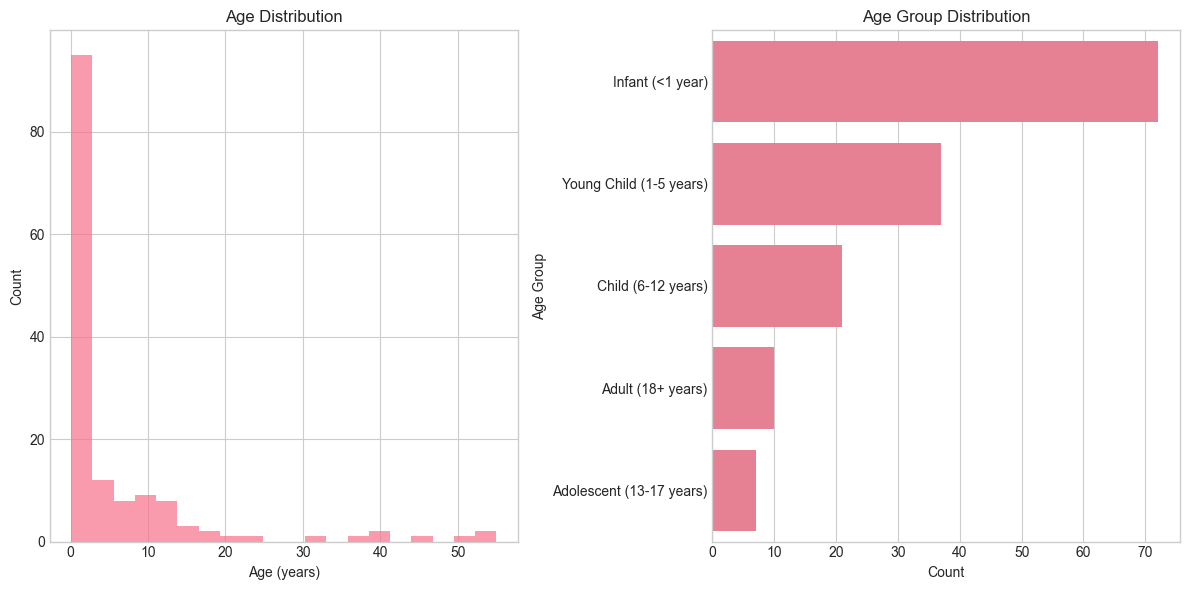

In [55]:
def categorize_age(age):
    if age < 1:
        return "Infant (<1 year)"
    elif age < 6:
        return "Young Child (1-5 years)"
    elif age < 13:
        return "Child (6-12 years)"
    elif age < 18:
        return "Adolescent (13-17 years)"
    else:
        return "Adult (18+ years)"
patient_info['Age Group'] = patient_info['Age (years)'].apply(categorize_age)
age_group_counts = patient_info['Age Group'].value_counts()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(patient_info['Age (years)'], bins=20, alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.grid(True)
plt.subplot(1, 2, 2)
sns.countplot(y='Age Group', data=patient_info, order=age_group_counts.index)
plt.title('Age Group Distribution')
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

## 3. Load and Process RR Interval Data

**Teaching Note:**  
RR intervals (the time between heartbeats) are often irregularly sampled. Converting to heart rate (bpm) and visualizing helps spot artifacts and physiological patterns.

In [56]:
def load_rr_intervals(file_path):
    with open(file_path, 'r') as f:
        rr_intervals = [float(line.strip()) for line in f if line.strip()]
    return np.array(rr_intervals)

selected_patients = []
for age_group in age_group_counts.index:
    group_patients = patient_info[patient_info['Age Group'] == age_group].head(2)
    selected_patients.extend(group_patients['File'].tolist())

rr_data = {}
for patient_id in selected_patients:
    file_path = f'{data_dir}/{patient_id}.txt'
    if os.path.exists(file_path):
        rr_data[patient_id] = load_rr_intervals(file_path)
        print(f"Loaded {len(rr_data[patient_id])} RR intervals for patient {patient_id}")

Loaded 171328 RR intervals for patient 4000
Loaded 185563 RR intervals for patient 4001
Loaded 105037 RR intervals for patient 404
Loaded 153896 RR intervals for patient 4002
Loaded 99188 RR intervals for patient 401
Loaded 89743 RR intervals for patient 402


### Convert RR Intervals to Heart Rate and Plot

**Teaching Note:**  
Heart rate (bpm) is easier to interpret than RR intervals (ms). Plotting the first 1000 beats for each patient gives a sense of variability and possible outliers.

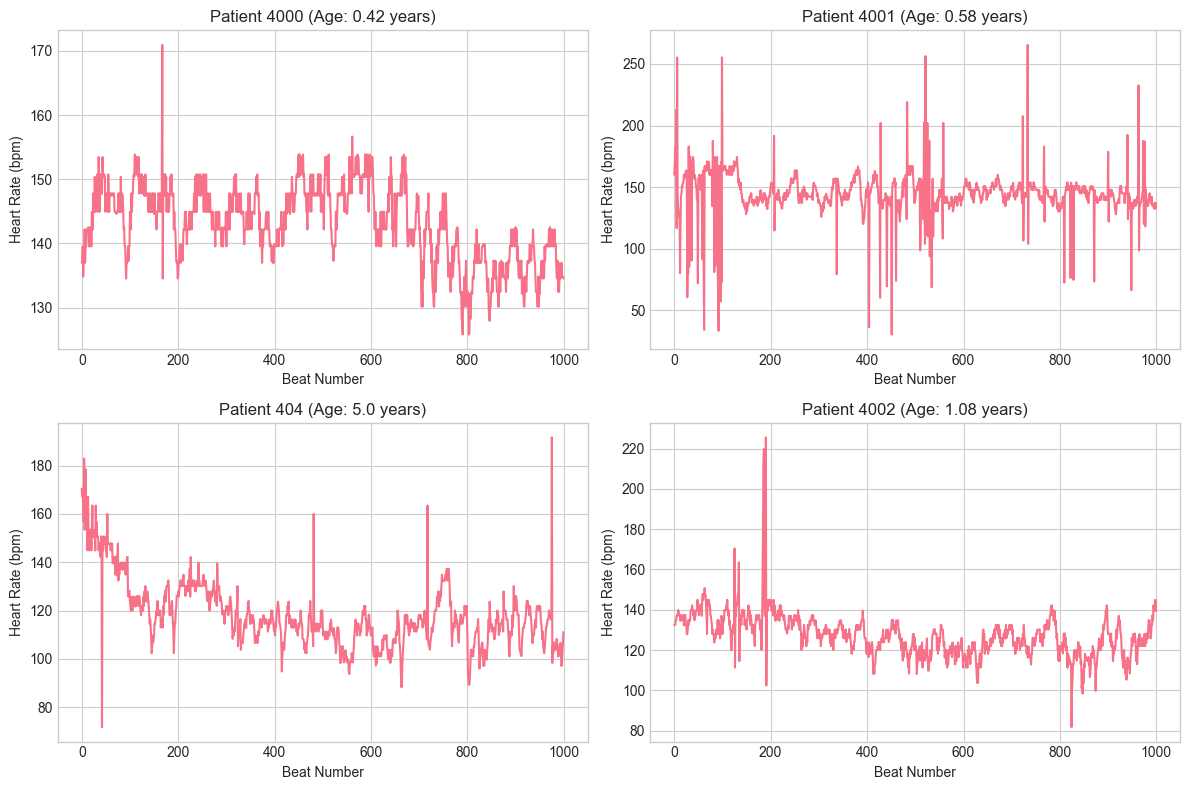

In [57]:
# Let's convert RR intervals (ms between heartbeats) to heart rate (beats per minute).
# This makes the data easier to interpret and visualize.

def rr_to_hr(rr_intervals):
    return 60000 / rr_intervals
hr_data = {pid: rr_to_hr(rr) for pid, rr in rr_data.items()}


# Now, let's plot the first 1000 heartbeats for a few patients.
# This helps us see the range and variability in heart rate across individuals.

plt.figure(figsize=(12, 8))
for i, (patient_id, hr) in enumerate(list(hr_data.items())[:4]):
    plt.subplot(2, 2, i+1)
    plt.plot(hr[:1000])
    patient_age = patient_info[patient_info['File'] == patient_id]['Age (years)'].values[0]
    plt.title(f'Patient {patient_id} (Age: {patient_age} years)')
    plt.xlabel('Beat Number')
    plt.ylabel('Heart Rate (bpm)')
    plt.grid(True)
plt.tight_layout()
plt.show()

# Output explanation:
# - Each subplot shows a different patient.
# - Look for patterns: Is the heart rate steady, variable, or are there outliers?
# - This visual check is a key first step before any modeling.

## 4. ARIMA Forecasting: Step-by-Step Walkthrough

Forecasting is like peering into the future using patterns from the past. In healthcare, this can help us anticipate patient needs, resource use, or physiological changes. ARIMA (AutoRegressive Integrated Moving Average) is a classic tool for time series forecasting, and this demo will show you how to use it on real heart rate variability (HRV) data.

We'll break down the ARIMA workflow into clear, beginner-friendly steps, explaining the reasoning and health relevance at each stage. Think of this as a "recipe" for time series forecasting in Python.

### 4.1 Select a Patient's Heart Rate Series

Let's start by picking a single patient's heart rate series to forecast. In real-world analysis, you might loop over many patients, but here we'll focus on one for clarity. We'll use the first 1000 beats to keep things fast and easy to visualize.

In [58]:
# Select a patient's heart rate series (first 1000 beats)
patient_id = list(hr_data.keys())[0]
series = pd.Series(hr_data[patient_id][:1000])
series.index = pd.RangeIndex(start=0, stop=len(series))
series.name = 'Heart Rate (bpm)'

### 4.2 Visualize the Series and Check for Stationarity

Before we can forecast, we need to understand our data. Is it stable over time, or does it wander? Stationarity means the statistical properties (like mean and variance) don't change as time goes on. Most forecasting models, including ARIMA, work best with stationary data.

We'll plot the heart rate series to look for trends or shifts, and then use the Augmented Dickey-Fuller (ADF) test—a standard statistical test—to check for stationarity. If the series isn't stationary, we'll need to transform it.

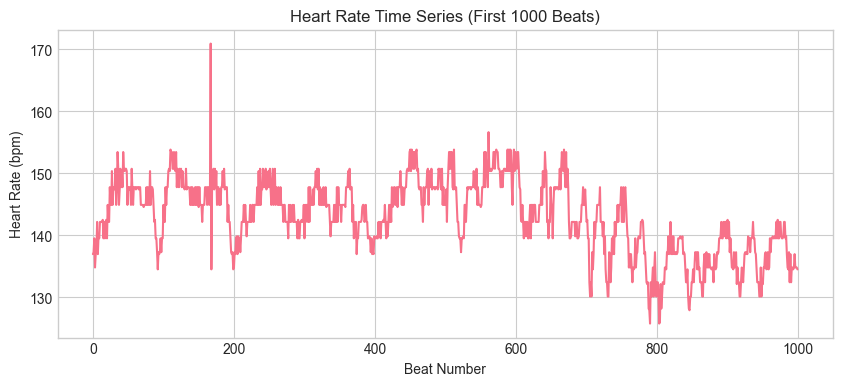

In [59]:
plt.figure(figsize=(10, 4))
plt.plot(series)
plt.title('Heart Rate Time Series (First 1000 Beats)')
plt.xlabel('Beat Number')
plt.ylabel('Heart Rate (bpm)')
plt.grid(True)
plt.show()

In [60]:
# Augmented Dickey-Fuller test for stationarity
adf_result = adfuller(series)
print(f'ADF Statistic: {adf_result[0]:.3f}')
print(f'p-value: {adf_result[1]:.3f}')
if adf_result[1] < 0.05:
    print('Series is likely stationary (rejects null hypothesis).')
else:
    print('Series is likely non-stationary (fails to reject null hypothesis).')

ADF Statistic: -3.125
p-value: 0.025
Series is likely stationary (rejects null hypothesis).


### 4.3 Make the Series Stationary (if needed)

If the series is not stationary, we need to "difference" it—subtract each value from the previous one. This helps remove trends and makes the data more stable, which is crucial for accurate forecasting. After differencing, we check again for stationarity. Sometimes, you may need to difference more than once, but usually once is enough for physiological data.

In [61]:
# First difference if needed
if adf_result[1] >= 0.05:
    diff_series = series.diff().dropna()
    plt.figure(figsize=(10, 4))
    plt.plot(diff_series)
    plt.title('First-Differenced Heart Rate Series')
    plt.xlabel('Beat Number')
    plt.ylabel('Differenced Heart Rate')
    plt.grid(True)
    plt.show()
    adf_result_diff = adfuller(diff_series)
    print(f'ADF Statistic (differenced): {adf_result_diff[0]:.3f}')
    print(f'p-value (differenced): {adf_result_diff[1]:.3f}')
    if adf_result_diff[1] < 0.05:
        print('Differenced series is stationary.')
    else:
        print('Differenced series is still not stationary.')
else:
    diff_series = series

### 4.4 Plot ACF and PACF to Choose ARIMA Parameters

ARIMA models have three key parameters: p (autoregressive lags), d (number of differences), and q (moving average lags). But how do you pick p and q? The answer: look at the autocorrelation (ACF) and partial autocorrelation (PACF) plots! These plots show how much the current value depends on previous values and help you decide how many lags to include.

- ACF: Shows correlation with previous values (lags).
- PACF: Shows correlation with previous values, controlling for the values in between.

Look for where the plots drop off to zero—this gives you a clue for p and q.

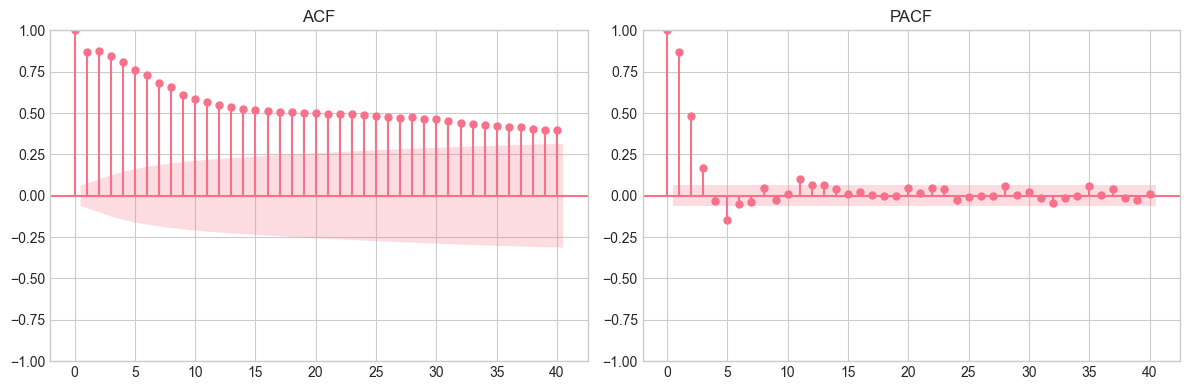

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diff_series, lags=40, ax=axes[0])
axes[0].set_title('ACF')
plot_pacf(diff_series, lags=40, ax=axes[1])
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

### 4.5 Fit the ARIMA Model

Now let's fit the ARIMA model! We'll use the parameters we chose (for demonstration, (1,1,1) is a safe starting point). The model will learn from the patterns in our data and get ready to make predictions. In real analysis, you might try several combinations and pick the best one using model selection criteria (like AIC/BIC).

In [63]:
# Fit ARIMA model (p=1, d=1 if differenced, q=1)
model = ARIMA(series, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       Heart Rate (bpm)   No. Observations:                 1000
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2339.123
Date:                Wed, 23 Apr 2025   AIC                           4684.245
Time:                        12:20:44   BIC                           4698.966
Sample:                             0   HQIC                          4689.840
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3375      0.046     -7.267      0.000      -0.429      -0.246
ma.L1         -0.2658      0.048     -5.509      0.000      -0.360      -0.171
sigma2         6.3258      0.120     52.526      0.0

### 4.6 Forecast Future Heart Rate Values

Time to make some predictions! We'll use our fitted ARIMA model to forecast the next 50 heartbeats. This is like asking, "Given what we've seen, what do we expect to happen next?" We'll plot the forecast alongside the observed data to see how well the model projects the future.

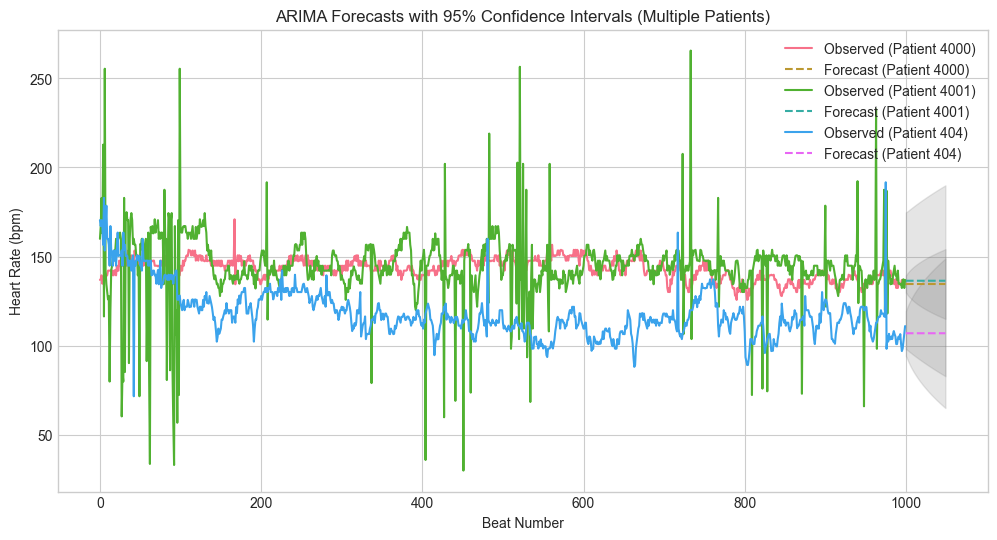

In [64]:
n_forecast = 50

plt.figure(figsize=(12, 6))
for i, (pid, hr) in enumerate(list(hr_data.items())[:3]):  # Try 3 patients for comparison
    series = pd.Series(hr[:1000])
    model = ARIMA(series, order=(1, 1, 1))
    model_fit = model.fit()
    forecast_result = model_fit.get_forecast(steps=n_forecast)
    forecast = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int(alpha=0.05)
    idx = np.arange(len(series), len(series) + n_forecast)
    plt.plot(series.values, label=f'Observed (Patient {pid})')
    plt.plot(idx, forecast, '--', label=f'Forecast (Patient {pid})')
    plt.fill_between(idx, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.2)

plt.title('ARIMA Forecasts with 95% Confidence Intervals (Multiple Patients)')
plt.xlabel('Beat Number')
plt.ylabel('Heart Rate (bpm)')
plt.legend()
plt.grid(True)
plt.show()

**Output explanation:**

- Each color represents a different patient’s observed and forecasted heart rate.
- The dashed lines show the ARIMA forecast for the next 50 beats.
- The shaded regions are 95% confidence intervals, showing the range where future values are likely to fall.
- Notice how the uncertainty grows as you forecast further into the future, and how different patients may have different forecast patterns.

### 4.7 Evaluate Forecast Accuracy (Optional)

How do we know if our forecast is any good? In real projects, we split the data into a training set (to fit the model) and a test set (to check predictions). We'll use common metrics like MAE (mean absolute error) and RMSE (root mean squared error) to measure accuracy. Lower values mean better predictions!

In [65]:
# Example: Split into train/test and evaluate
split = int(0.8 * len(series))
train, test = series[:split], series[split:]
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()
predictions = model_fit.forecast(steps=len(test))
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

MAE: 9.16
RMSE: 12.18


#### How do you know if your ARIMA model is any good?

- **MAE (Mean Absolute Error)** and **RMSE (Root Mean Squared Error)** tell you, on average, how far off your predictions are from the actual values. For heart rate, these are measured in beats per minute (bpm).
- As a rule of thumb, compare these errors to the typical range or standard deviation of your heart rate data. For example, if your heart rate varies by 10 bpm and your MAE is 5 bpm, your model is capturing about half the variation.
- In clinical or health research, an error of 5 bpm might be acceptable for some applications (like general trend forecasting), but too high for others (like arrhythmia detection).
- **If your errors seem large:** Try improving your model by tuning ARIMA parameters, adding more preprocessing (e.g., outlier removal), or exploring other forecasting methods.

> **Tip:** Always visualize your predictions alongside the actual data. Sometimes a model with a "decent" error still misses important patterns!

**Checkpoint:**

- Can you explain what each ARIMA parameter (p, d, q) controls? (Hint: p = past values, d = differences, q = past errors)
- Try changing the parameters and see how the forecast changes!
- What would happen if you skipped the stationarity check?

**Common beginner mistakes:**

- Not checking for stationarity before fitting ARIMA (the model won't work well!)
- Using the wrong d parameter (over- or under-differencing can distort the data)
- Ignoring model diagnostics (residuals should look like white noise—if not, your model may be missing something)
- Forgetting to inverse-transform differenced or log-transformed data when interpreting forecasts (always bring predictions back to the original scale)